In [15]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

In [16]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


def print_statevector(label, statevector):
    print(f"Trạng thái {label}: {statevector}")

In [17]:
print("(a) |u> = |111>")
qc_a = QuantumCircuit(3)
qc_a.mcp(np.pi, [0, 1], 2)

input_a = Statevector.from_label("111")
output_a = input_a.evolve(qc_a)

print("\nResult:")
print(output_a.draw("text"))

print("\n(b) |u> = |000>")
qc_b = QuantumCircuit(3)
qc_b.x([0, 1, 2])
qc_b.mcp(np.pi, [0, 1], 2)
qc_b.x([0, 1, 2])

input_b = Statevector.from_label("000")
output_b = input_b.evolve(qc_b)

print("\nResult:")
print(output_b.draw("text"))

print("\n(c) |u> = |+++>")
qc_c = QuantumCircuit(3)
qc_c.h([0, 1, 2])
qc_c.x([0, 1, 2])
qc_c.mcp(np.pi, [0, 1], 2)
qc_c.x([0, 1, 2])
qc_c.h([0, 1, 2])

input_c = Statevector.from_label("+++")
output_c = input_c.evolve(qc_c)

print("\nResult:")
print(output_c.draw("text"))

print("\n(d) |u> = |--->")
qc_d = QuantumCircuit(3)
qc_d.h([0, 1, 2])
qc_d.mcp(np.pi, [0, 1], 2)
qc_d.h([0, 1, 2])

input_d = Statevector.from_label("---")
output_d = input_d.evolve(qc_d)

print("\nResult:")
print(output_d.draw("text"))

(a) |u> = |111>

Result:
[ 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,-1.+0.j]

(b) |u> = |000>

Result:
[-1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]

(c) |u> = |+++>

Result:
[-0.35355339-5.4473525e-34j,-0.35355339-5.4473525e-34j,
 -0.35355339-5.4473525e-34j,-0.35355339-5.4473525e-34j,
 -0.35355339+5.4473525e-34j,-0.35355339+5.4473525e-34j,
 -0.35355339+5.4473525e-34j,-0.35355339+5.4473525e-34j]

(d) |u> = |--->

Result:
[-0.35355339-5.4473525e-34j, 0.35355339+5.4473525e-34j,
  0.35355339+5.4473525e-34j,-0.35355339-5.4473525e-34j,
  0.35355339-5.4473525e-34j,-0.35355339+5.4473525e-34j,
 -0.35355339+5.4473525e-34j, 0.35355339-5.4473525e-34j]


In [18]:
qc = QuantumCircuit(3)

qc.x([0, 1, 2])
qc.mcp(np.pi, [0, 1], 2)
qc.x([0, 1, 2])


print("\nVoi input |000>:")
vec_000 = Statevector.from_label("000").evolve(qc)
print(vec_000.draw("text"))

print("\nVoi input |001>:")
vec_001 = Statevector.from_label("001").evolve(qc)
print(vec_001.draw("text"))


Voi input |000>:
[-1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]

Voi input |001>:
[0.+0.00000000e+00j,1.-5.55111512e-17j,0.+0.00000000e+00j,
 0.+0.00000000e+00j,0.+0.00000000e+00j,0.+0.00000000e+00j,
 0.+0.00000000e+00j,0.+0.00000000e+00j]


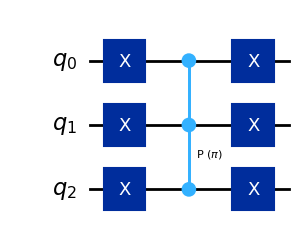

In [19]:
qc.draw("mpl")

Simulation results for n=4, Target=|0000> after 3 iterations:
{'0000': 984, '1010': 5, '1101': 5, '1000': 5, '1110': 3, '0010': 3, '0100': 3, '0101': 3, '1111': 3, '1011': 2, '0001': 2, '0110': 2, '1100': 1, '0011': 1, '0111': 1, '1001': 1}


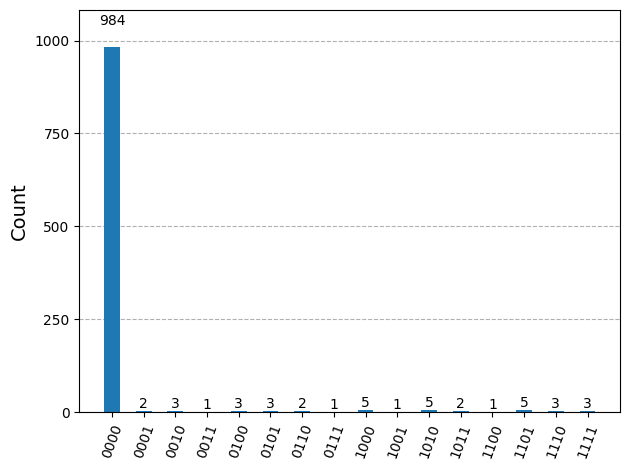

In [20]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt


def initialize_s(qc, n):
    """Create equal superposition state |s>"""
    qc.h(range(n))


def oracle_0000(qc, n):
    """
    Oracle marking |0000>
    X - MCP(pi) - X
    """
    qc.x(range(n))
    qc.mcp(np.pi, list(range(n - 1)), n - 1)
    qc.x(range(n))


def diffuser(qc, n):
    """
    Diffuser operator
    """
    qc.h(range(n))
    qc.x(range(n))
    qc.mcp(np.pi, list(range(n - 1)), n - 1)
    qc.x(range(n))
    qc.h(range(n))


n = 4  # number of qubits
qc = QuantumCircuit(n)

initialize_s(qc, n)
qc.barrier()

iterations = 3
for i in range(iterations):
    oracle_0000(qc, n)
    qc.barrier()
    diffuser(qc, n)
    qc.barrier()

qc.measure_all()


simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()

print(f"Simulation results for n={n}, Target=|0000> after {iterations} iterations:")
sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))
print(sorted_counts)

plot_histogram(counts)

In [21]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT


def qft_3qubit(qc):
    """Implement QFT for 3 qubits"""
    # Apply H to qubit 0
    qc.h(0)
    # Controlled-R2 from qubit 1 to qubit 0
    qc.cp(np.pi / 2, 1, 0)
    # Controlled-R3 from qubit 2 to qubit 0
    qc.cp(np.pi / 4, 2, 0)

    # Apply H to qubit 1
    qc.h(1)
    # Controlled-R2 from qubit 2 to qubit 1
    qc.cp(np.pi / 2, 2, 1)

    # Apply H to qubit 2
    qc.h(2)

    # SWAP qubits 0 and 2
    qc.swap(0, 2)


# Test with different basis states
test_states = ["000", "001", "010", "011", "100", "101", "110", "111"]

print("Testing QFT 3-qubit implementation:\n")
for state in test_states:
    qc = QuantumCircuit(3)
    qft_3qubit(qc)

    input_state = Statevector.from_label(state)
    output_state = input_state.evolve(qc)

    print(f"Input: |{state}>")
    print(f"Output: {output_state.draw('text')}\n")

# Compare with built-in QFT
print("\nComparing with Qiskit built-in QFT:")
qc_custom = QuantumCircuit(3)
qft_3qubit(qc_custom)

qc_builtin = QuantumCircuit(3)
qc_builtin.append(QFT(3), range(3))

# Test with |101> state
test_input = Statevector.from_label("101")
output_custom = test_input.evolve(qc_custom)
output_builtin = test_input.evolve(qc_builtin)

print("Input: |101>")
print(f"Custom QFT: {output_custom.draw('text')}")
print(f"Built-in QFT: {output_builtin.draw('text')}")

Testing QFT 3-qubit implementation:

Input: |000>
Output: [0.35355339+0.j,0.35355339+0.j,0.35355339+0.j,0.35355339+0.j,
 0.35355339+0.j,0.35355339+0.j,0.35355339+0.j,0.35355339+0.j]

Input: |001>
Output: [ 0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
 -0.35355339+0.j,-0.35355339+0.j,-0.35355339+0.j,-0.35355339+0.j]

Input: |010>
Output: [ 3.53553391e-01+0.j        , 3.53553391e-01+0.j        ,
 -3.53553391e-01+0.j        ,-3.53553391e-01+0.j        ,
  2.16489014e-17+0.35355339j, 2.16489014e-17+0.35355339j,
 -2.16489014e-17-0.35355339j,-2.16489014e-17-0.35355339j]

Input: |011>
Output: [ 3.53553391e-01+0.j        , 3.53553391e-01+0.j        ,
 -3.53553391e-01+0.j        ,-3.53553391e-01+0.j        ,
 -2.16489014e-17-0.35355339j,-2.16489014e-17-0.35355339j,
  2.16489014e-17+0.35355339j, 2.16489014e-17+0.35355339j]

Input: |100>
Output: [ 3.53553391e-01+0.j        ,-3.53553391e-01+0.j        ,
  2.16489014e-17+0.35355339j,-2.16489014e-17-0.35355339j,
  2.50000000e-01+0

/tmp/ipython-input-148274173.py:46: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_builtin.append(QFT(3), range(3))
